<a href="https://colab.research.google.com/github/pedrodamiaoluz/predict-autism-spectrum-tea/blob/main/predict_autism_spectrum_asd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Instalações de bibliotecas necessárias

In [17]:
import os
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay

  Na literatura médica: Esse dataset usa um teste oficial chamado AQ-10 Adult (Autism Spectrum Quotient 10).Se você pesquisar no Google por "AQ-10 test pdf", foi usado para coletar esses dados.

  Que essas questões são A1_Score até A10_Score
  [AQ-10 test pdf](https://bibliotecadeinstrumentos.com.br/instrumentos/autism-spectrum-quotient-adult-aq-10__2d1938f9-565e-44b8-8dd9-52d34ece6bf4/pdf)

In [18]:
texto_das_perguntas = {
    'A1_Score': 'Percebe pequenos sons que os outros não notam?',
    'A2_Score': 'Tende a focar nos pequenos detalhes em vez do todo?',
    'A3_Score': 'Tem facilidade em fazer mais de uma coisa ao mesmo tempo?',
    'A4_Score': 'Percebe facilmente quando alguém está ficando entediado conversando com você?',
    'A5_Score': 'Tem facilidade em "ler nas entrelinhas" o que as pessoas dizem?',
    'A6_Score': 'Tem facilidade em descobrir as intenções das outras pessoas?',
    'A7_Score': 'Entende facilmente as intenções dos personagens em filmes ou livros?',
    'A8_Score': 'Gosta de colecionar informações sobre categorias (carros, plantas, etc.)?',
    'A9_Score': 'Sabe o que alguém está sentindo apenas olhando para o rosto da pessoa?',
    'A10_Score': 'Tem dificuldade em descobrir as intenções das pessoas?'
}

   Recuperando dados do dataset



In [19]:
path = kagglehub.dataset_download("stealthtechnologies/predict-autism-spectrum-disorder-asd")

csv_path=os.path.join(path,"Autism.csv")

df = pd.read_csv(csv_path)
df

Using Colab cache for faster access to the 'predict-autism-spectrum-disorder-asd' dataset.


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
700,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
701,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
702,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


  Removendo dados irrelevantes

In [20]:
colunas_para_remover = ['age_desc', 'relation', 'ethnicity', 'jundice', 'contry_of_res', 'used_app_before', 'result']
df = df.drop(columns=colunas_para_remover, errors='ignore')
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,austim,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26,f,no,NO
1,1,1,0,1,0,0,0,1,0,1,24,m,yes,NO
2,1,1,0,1,1,0,1,1,1,1,27,m,yes,YES
3,1,1,0,1,0,0,1,1,0,1,35,f,yes,NO
4,1,0,0,0,0,0,0,1,0,0,40,f,no,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,25,f,no,YES
700,1,0,0,0,0,0,0,1,0,1,34,m,no,NO
701,1,0,1,1,1,0,1,1,0,1,24,f,no,YES
702,1,0,0,1,1,0,1,0,1,1,35,m,no,NO


  Transformar dados em numéricos

In [21]:
encoder = LabelEncoder()
for coluna in df.select_dtypes(include=['object']).columns:
    df[coluna] = encoder.fit_transform(df[coluna])
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,austim,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,9,0,0,0
1,1,1,0,1,0,0,0,1,0,1,7,1,1,0
2,1,1,0,1,1,0,1,1,1,1,10,1,1,1
3,1,1,0,1,0,0,1,1,0,1,18,0,1,0
4,1,0,0,0,0,0,0,1,0,0,24,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,8,0,0,1
700,1,0,0,0,0,0,0,1,0,1,17,1,0,0
701,1,0,1,1,1,0,1,1,0,1,7,0,0,1
702,1,0,0,1,1,0,1,0,1,1,18,1,0,0


In [22]:
# Separandos as características (X) do alvo (Y - que a coluna "Class/ADS")
X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

  Criando o Modelo

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
# Técnica de Balanciamento
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: class_weights[0], 1: class_weights[1]}
class_weights

{0: np.float64(0.6865853658536586), 1: np.float64(1.8398692810457515)}

In [25]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,297 (59.75 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [26]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
historyADS = model.fit(X_train, y_train, epochs=40, batch_size=32, class_weight=class_weights, validation_split=0.2)

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.7044 - loss: 0.5295 - val_accuracy: 0.8761 - val_loss: 0.5467
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8311 - loss: 0.3224 - val_accuracy: 0.8584 - val_loss: 0.4963
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8667 - loss: 0.2397 - val_accuracy: 0.9115 - val_loss: 0.4357
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8867 - loss: 0.2209 - val_accuracy: 0.9558 - val_loss: 0.3784
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9222 - loss: 0.1678 - val_accuracy: 0.9646 - val_loss: 0.3284
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9200 - loss: 0.1865 - val_accuracy: 0.9646 - val_loss: 0.2833
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9467 - loss: 0.1179 - val_accuracy: 0.9823 - val_loss: 0.2482
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9533 - loss: 0.1268 - val_accuracy: 0.9823 - v

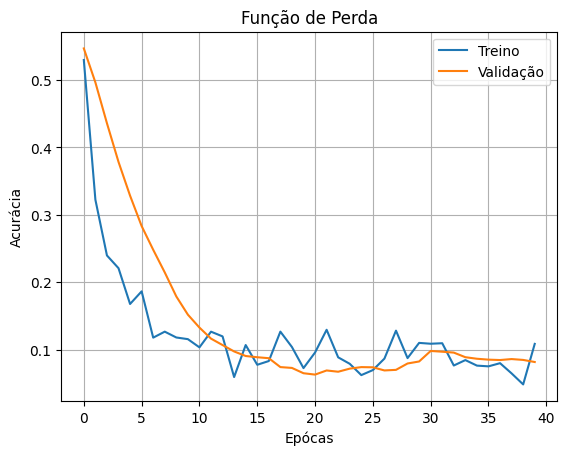

In [28]:
plt.plot(historyADS.history['loss'], label='Treino')
plt.plot(historyADS.history['val_loss'], label='Validação')
plt.title('Função de Perda')
plt.xlabel('Epócas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.grid(True)
plt.savefig('loss_function.png', bbox_inches='tight', dpi=300)
plt.show()

In [29]:
output_proba = model.predict(X_test)

output_proba = output_proba.reshape(output_proba.shape[0])

output_pred = (output_proba > 0.5).astype(int)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [30]:
def model_predict(X_test):
    output_proba = model.predict(X_test)
    output_proba = output_proba.reshape(output_proba.shape[0])
    output_pred = (output_proba > 0.5).astype(int)
    return output_pred

In [31]:
print(classification_report(y_test, output_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       105
           1       0.88      1.00      0.94        36

    accuracy                           0.96       141
   macro avg       0.94      0.98      0.96       141
weighted avg       0.97      0.96      0.97       141



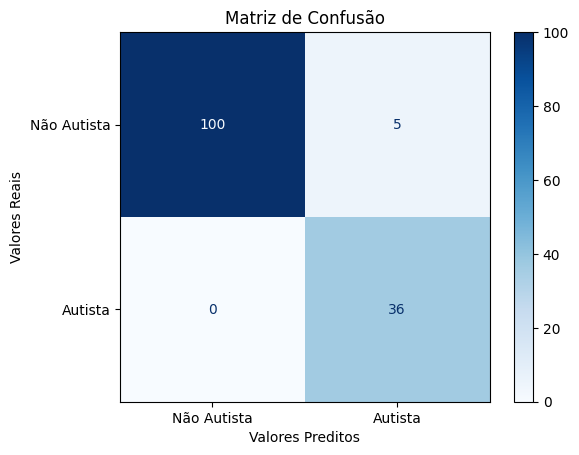

In [32]:
cm = confusion_matrix(y_test, output_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Autista', 'Autista'])
cmd.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()